# Modeling Non-Linear Patterns with Activation Functions

A standalone PyTorch study notebook on using **ReLU activation functions** to model relationships that cannot be represented well by a single straight line.

### Learning objectives
By the end of this notebook, you will be able to:

- recognize why a purely linear neural network cannot capture a curved relationship;
- standardize input and target tensors before training;
- build a small non-linear network with `nn.ReLU()`;
- train the network with mean squared error and stochastic gradient descent;
- convert predictions back to their original units; and
- compare a linear baseline with a ReLU network.

> **Repository note:** This notebook is rewritten as a self-contained learning artifact. It does not depend on the course's `helper_utils` module.

## 1. Imports and reproducibility

We only need PyTorch and Matplotlib. A fixed random seed makes the initialization reproducible.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(27)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


## 2. Delivery dataset

The input is delivery **distance in miles** and the target is delivery **time in minutes**. The relationship bends: time rises quickly at shorter distances and then increases more slowly. That is the type of pattern a single linear transformation cannot represent well.

In [2]:
# Combined delivery dataset: shorter distances and longer distances
# Input feature: distance in miles

distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Target: delivery time in minutes

times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.70], [26.52], [32.47], [37.15], [42.35],
    [46.10], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.80], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

print("distances shape:", distances.shape)
print("times shape:", times.shape)

distances shape: torch.Size([39, 1])
times shape: torch.Size([39, 1])


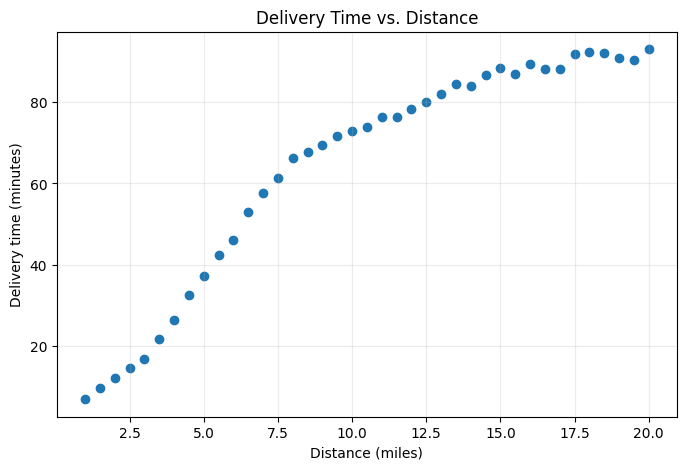

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(distances.numpy(), times.numpy())
plt.xlabel("Distance (miles)")
plt.ylabel("Delivery time (minutes)")
plt.title("Delivery Time vs. Distance")
plt.grid(alpha=0.25)
plt.show()

## 3. Standardization

The course introduces **standardization** (often called z-score normalization):

\[
z = \frac{x - \mu}{\sigma}
\]

where $\mu$ is the mean and $\sigma$ is the standard deviation.

The model is trained on standardized distances and standardized delivery times. The transformation changes the scale, not the underlying shape of the relationship.

In [4]:
# Statistics computed from the training data

distances_mean = distances.mean()
distances_std = distances.std()
times_mean = times.mean()
times_std = times.std()

# Standardized tensors

distances_norm = (distances - distances_mean) / distances_std
times_norm = (times - times_mean) / times_std

print(f"Distance mean: {distances_mean.item():.3f}")
print(f"Distance std:  {distances_std.item():.3f}")
print(f"Time mean:     {times_mean.item():.3f}")
print(f"Time std:      {times_std.item():.3f}")

Distance mean: 10.500
Distance std:  5.701
Time mean:     64.071
Time std:      27.938


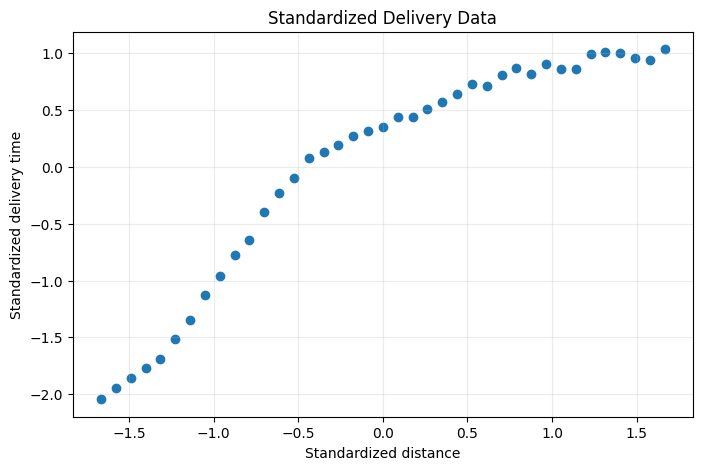

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(distances_norm.numpy(), times_norm.numpy())
plt.xlabel("Standardized distance")
plt.ylabel("Standardized delivery time")
plt.title("Standardized Delivery Data")
plt.grid(alpha=0.25)
plt.show()

## 4. Why an activation function matters

A stack of linear layers without a non-linear activation still collapses to another linear transformation. To model a curved pattern, the network needs a non-linear operation between layers.

The activation used here is **ReLU**:

\[
\mathrm{ReLU}(x) = \max(0, x)
\]

Negative inputs become zero, while positive inputs pass through unchanged. In a hidden layer, multiple ReLU units allow the network to combine piecewise-linear segments and create bends in the learned function.

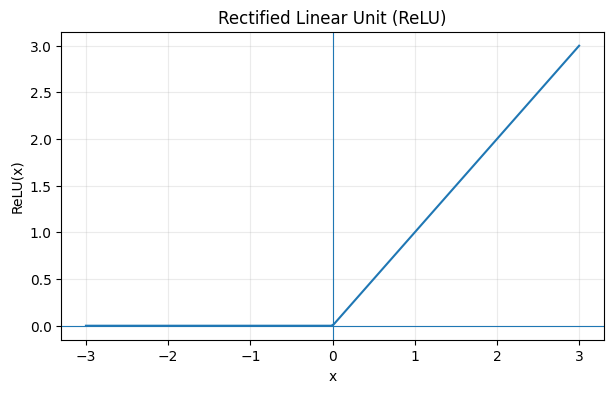

In [6]:
# Visualize ReLU directly

x_relu = torch.linspace(-3, 3, 200)
y_relu = torch.relu(x_relu)

plt.figure(figsize=(7, 4))
plt.plot(x_relu.numpy(), y_relu.numpy())
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.title("Rectified Linear Unit (ReLU)")
plt.grid(alpha=0.25)
plt.show()

## 5. Build the non-linear neural network

Architecture:

```text
1 input feature
      ↓
Linear(1 → 3)
      ↓
    ReLU
      ↓
Linear(3 → 1)
      ↓
1 predicted value
```

- `nn.Linear(1, 3)` maps one distance value to three hidden activations.
- `nn.ReLU()` introduces non-linearity.
- `nn.Linear(3, 1)` combines those hidden activations into one predicted delivery time.

In [7]:
model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

print(model)
print()
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Sequential(
  (0): Linear(in_features=1, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
)

Trainable parameters: 10


## 6. Loss function and optimizer

This is a regression problem, so we use **mean squared error (MSE)**. The optimizer is **stochastic gradient descent (SGD)** with a learning rate of `0.01`, matching the course lab.

In [8]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## 7. Train the network

Each epoch follows the standard PyTorch training sequence:

1. clear old gradients;
2. run a forward pass;
3. compute the loss;
4. run backpropagation;
5. update the parameters.

We also store the loss so that training can be inspected after the loop.

In [9]:
num_epochs = 3000
loss_history = []

for epoch in range(num_epochs):
    optimizer.zero_grad()

    predictions_norm = model(distances_norm)
    loss = loss_function(predictions_norm, times_norm)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1:4d}/{num_epochs} | Loss: {loss.item():.6f}")

print()
print(f"Final loss: {loss_history[-1]:.6f}")

Epoch  500/3000 | Loss: 0.007089
Epoch 1000/3000 | Loss: 0.004626


Epoch 1500/3000 | Loss: 0.003918
Epoch 2000/3000 | Loss: 0.003490


Epoch 2500/3000 | Loss: 0.003254
Epoch 3000/3000 | Loss: 0.003144

Final loss: 0.003144


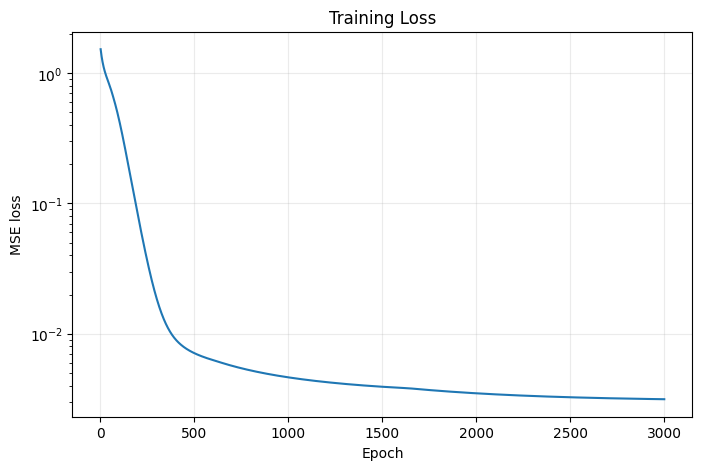

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training Loss")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.show()

## 8. Inspect the fitted relationship in the original units

Because the network predicts standardized delivery time, its output must be converted back to minutes:

```python
actual_time = standardized_prediction * times_std + times_mean
```

For a smooth fitted curve, we generate a dense sequence of distance values, standardize them, predict with the model, and then de-standardize the predictions.

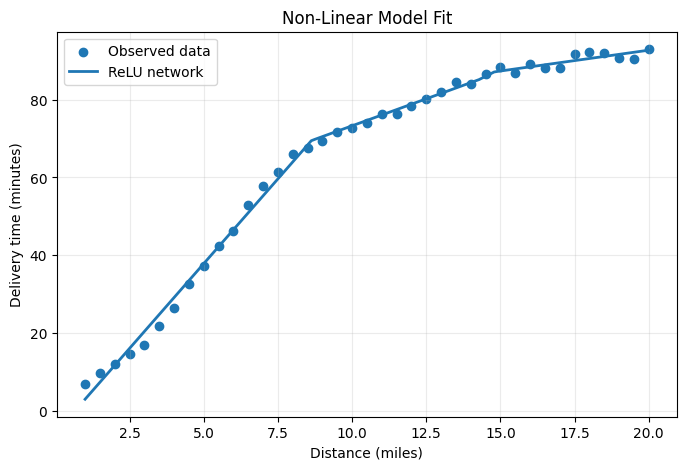

In [11]:
model.eval()

with torch.no_grad():
    distance_grid = torch.linspace(distances.min(), distances.max(), 300).reshape(-1, 1)
    distance_grid_norm = (distance_grid - distances_mean) / distances_std

    fitted_time_norm = model(distance_grid_norm)
    fitted_time = fitted_time_norm * times_std + times_mean

plt.figure(figsize=(8, 5))
plt.scatter(distances.numpy(), times.numpy(), label="Observed data")
plt.plot(distance_grid.numpy(), fitted_time.numpy(), linewidth=2, label="ReLU network")
plt.xlabel("Distance (miles)")
plt.ylabel("Delivery time (minutes)")
plt.title("Non-Linear Model Fit")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. Make a prediction

The model was trained on standardized values, so inference must use the **same training mean and standard deviation**. After prediction, the output is converted back to minutes.

In [12]:
distance_to_predict = 5.1

with torch.no_grad():
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)

    # Apply the same transformation used during training
    new_distance_norm = (distance_tensor - distances_mean) / distances_std

    # Predict on the standardized scale
    predicted_time_norm = model(new_distance_norm)

    # Convert prediction back to minutes
    predicted_time_actual = predicted_time_norm * times_std + times_mean

print(f"Prediction for a {distance_to_predict:.1f}-mile delivery: {predicted_time_actual.item():.1f} minutes")

Prediction for a 5.1-mile delivery: 38.7 minutes


### Simple operational decision rule

The original lab connects the prediction to a delivery decision. Here the promise threshold is **45 minutes**. If the prediction is within that limit, a bike is used for distances up to 3 miles and a car otherwise.

In [13]:
predicted_minutes = predicted_time_actual.item()

if predicted_minutes > 45:
    decision = "Do NOT promise delivery in under 45 minutes."
elif distance_to_predict <= 3:
    decision = "Delivery is feasible within 45 minutes; use a bike."
else:
    decision = "Delivery is feasible within 45 minutes; use a car."

print("Decision:", decision)

Decision: Delivery is feasible within 45 minutes; use a car.


## 10. Extension — compare a linear baseline with the ReLU network

This section goes one step beyond the original exercise to make the core lesson visually explicit. A one-layer linear model is trained on the same standardized data and plotted beside the ReLU network.

The comparison isolates the architectural difference: **the activation function gives the model the capacity to bend**.

In [14]:
# Reproducible linear baseline

torch.manual_seed(27)
linear_model = nn.Linear(1, 1)
linear_optimizer = optim.SGD(linear_model.parameters(), lr=0.01)
linear_loss_history = []

for epoch in range(num_epochs):
    linear_optimizer.zero_grad()
    linear_pred = linear_model(distances_norm)
    linear_loss = loss_function(linear_pred, times_norm)
    linear_loss.backward()
    linear_optimizer.step()
    linear_loss_history.append(linear_loss.item())

with torch.no_grad():
    linear_fit_norm = linear_model(distance_grid_norm)
    linear_fit = linear_fit_norm * times_std + times_mean

print(f"Linear model final loss: {linear_loss_history[-1]:.6f}")
print(f"ReLU model final loss:   {loss_history[-1]:.6f}")

Linear model final loss: 0.109451
ReLU model final loss:   0.003144


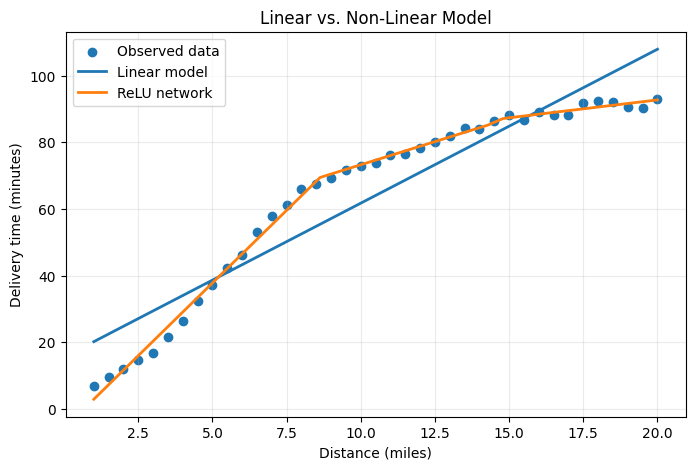

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(distances.numpy(), times.numpy(), label="Observed data")
plt.plot(distance_grid.numpy(), linear_fit.numpy(), linewidth=2, label="Linear model")
plt.plot(distance_grid.numpy(), fitted_time.numpy(), linewidth=2, label="ReLU network")
plt.xlabel("Distance (miles)")
plt.ylabel("Delivery time (minutes)")
plt.title("Linear vs. Non-Linear Model")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 11. Key takeaways

- A purely linear architecture can only represent a linear input-output relationship.
- `ReLU` introduces the non-linearity needed to model bends in the data.
- Standardization can make optimization more stable by putting variables on a more manageable scale.
- Training follows the same PyTorch pattern: **forward pass → loss → backward pass → optimizer step**.
- Any preprocessing applied during training must also be applied during inference.
- If the target was standardized, predictions must be transformed back to the original unit before they are interpreted.

### PyTorch objects used

| Purpose | PyTorch object |
|---|---|
| Linear layer | `nn.Linear` |
| Activation | `nn.ReLU` |
| Model container | `nn.Sequential` |
| Regression loss | `nn.MSELoss` |
| Optimizer | `optim.SGD` |
| Disable gradients for inference | `torch.no_grad()` |

---

`02_modeling_non_linear_patterns_with_activation_functions.ipynb`